In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 한글폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


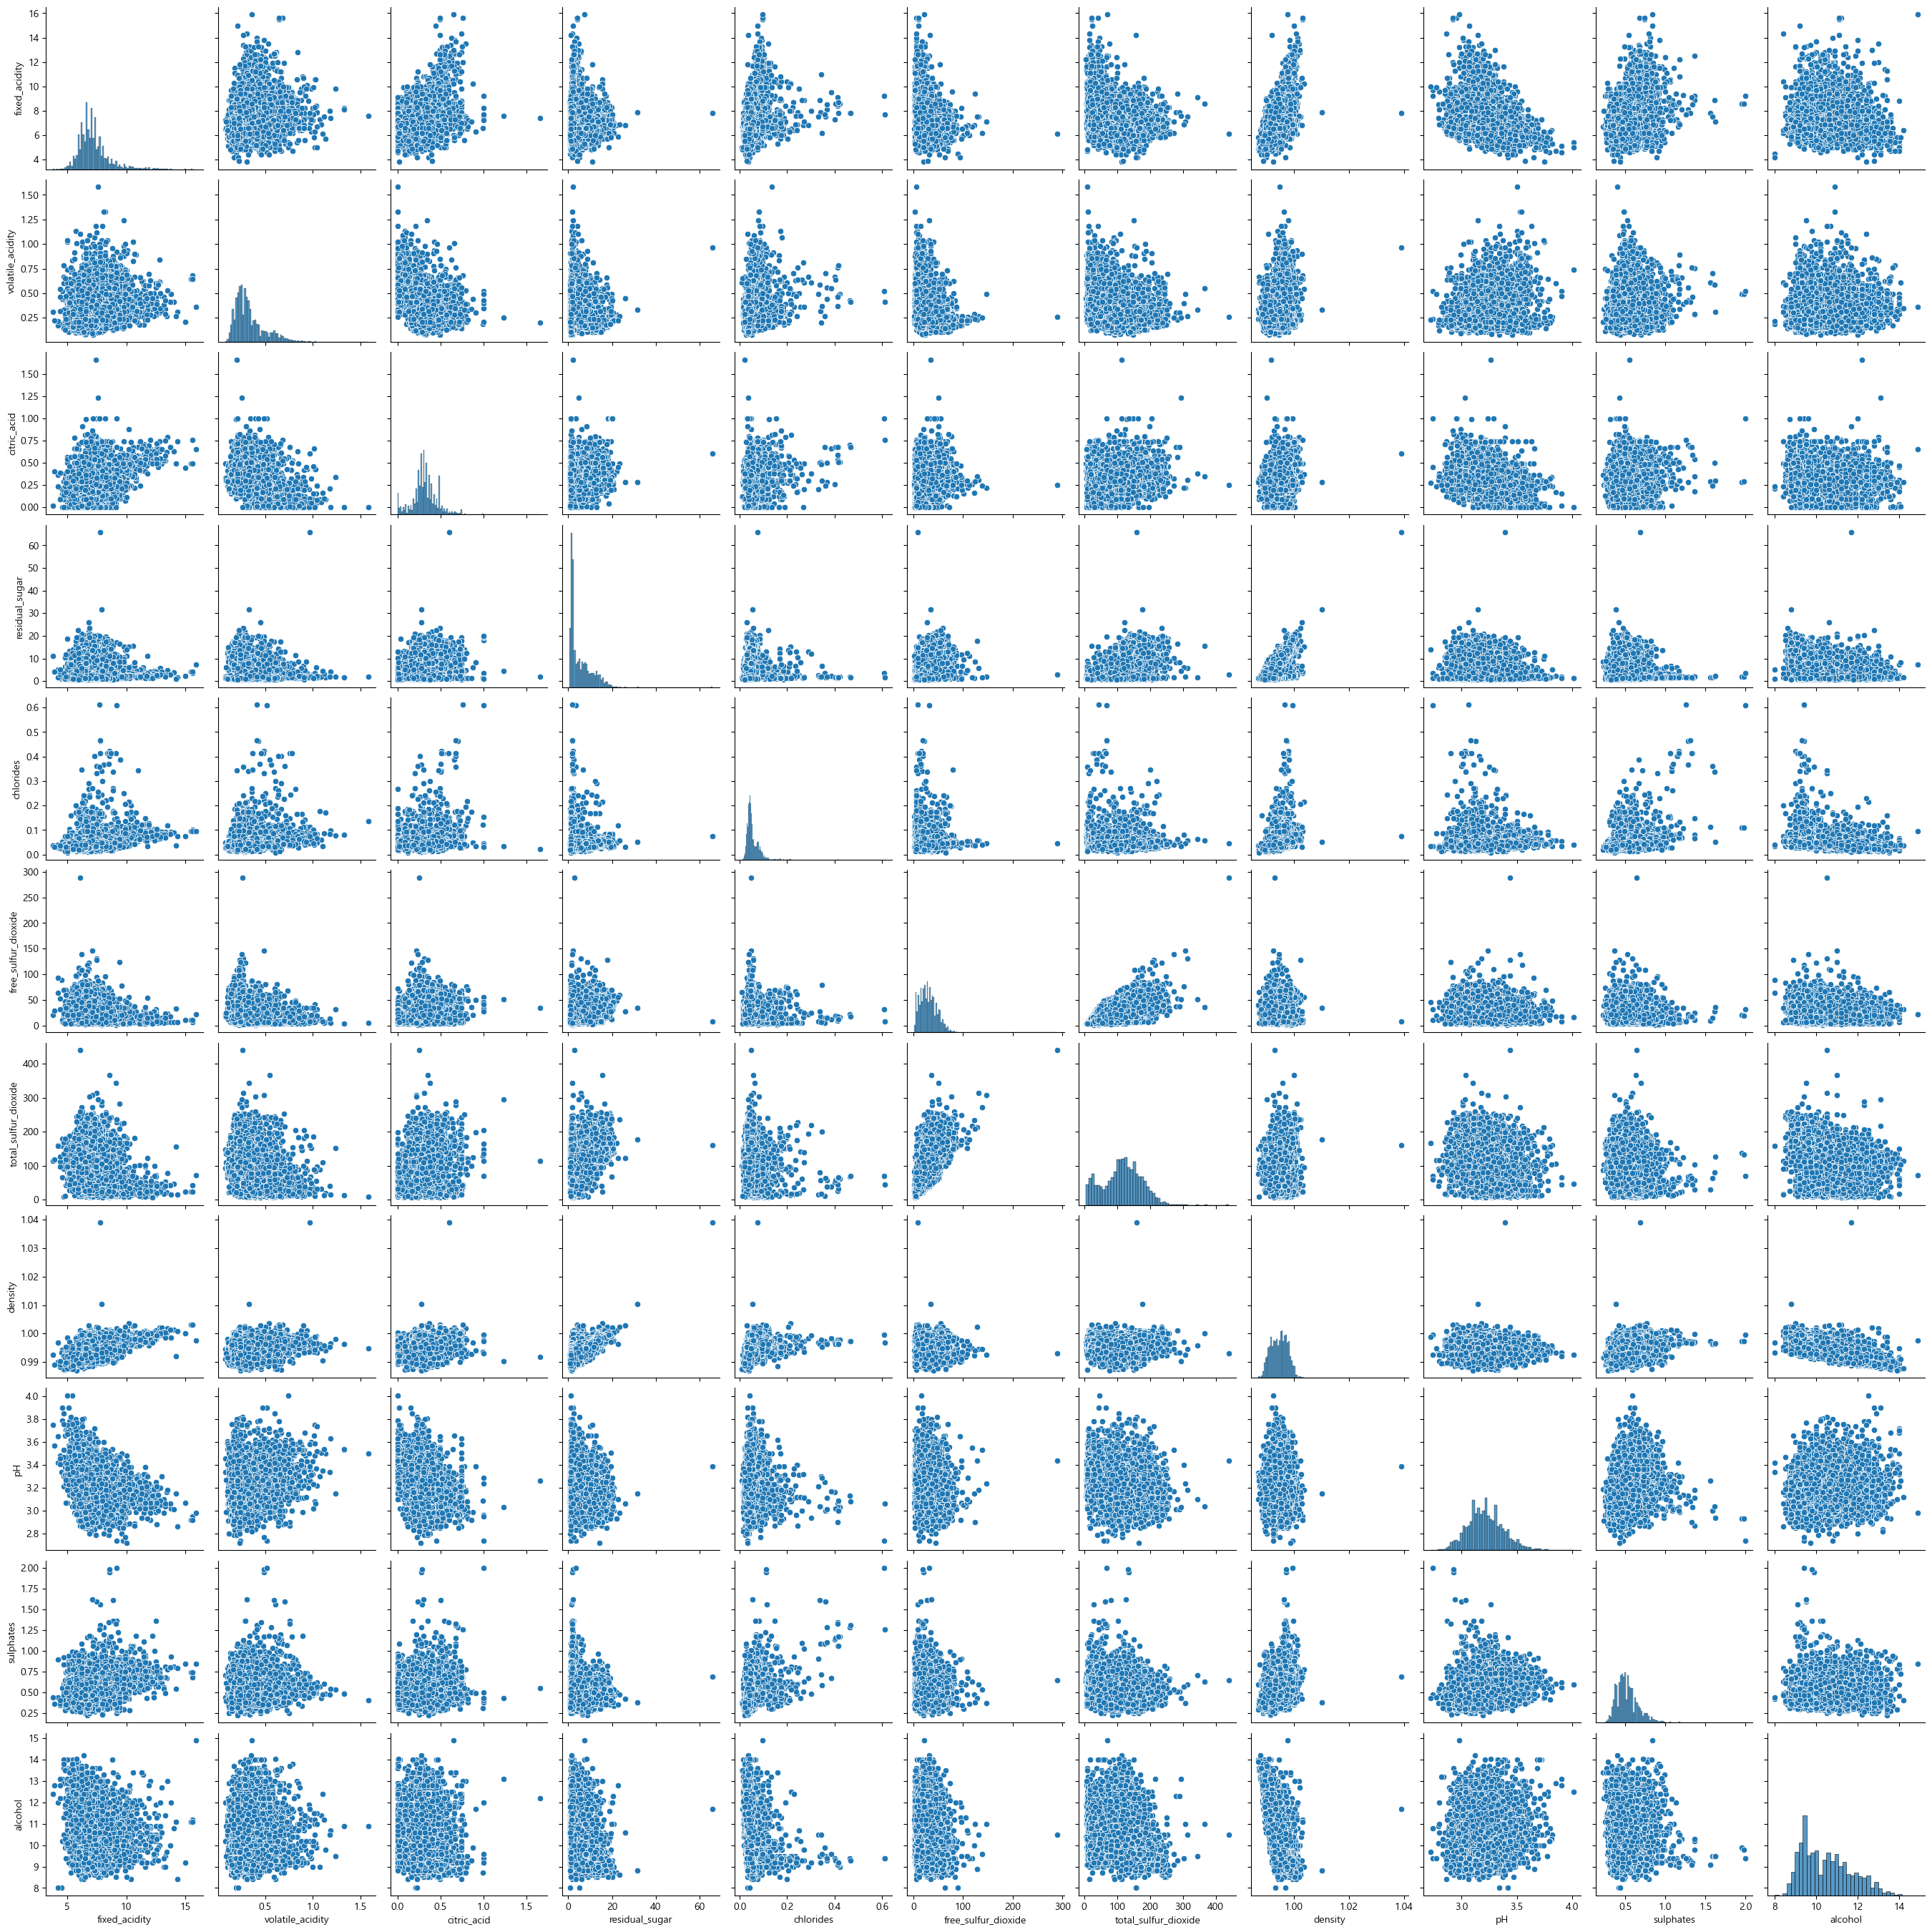

In [18]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets 
# fig, ax = plt.subplots(figsize=(10,6))
sns.pairplot(X)

In [27]:
# 왜도 계산 보완
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
skew_series = X.skew(numeric_only=True).sort_values(ascending=False)
high_skew_feature =  skew_series[skew_series > 1].index
# sns.pairplot(X[high_skew_feature])
X1 = X[high_skew_feature].copy()
x_train,x_test,y_train,y_test = train_test_split(X1,y,test_size=0.2,random_state=42)
model = LinearRegression()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.11469263111748995

0.11067724627716535

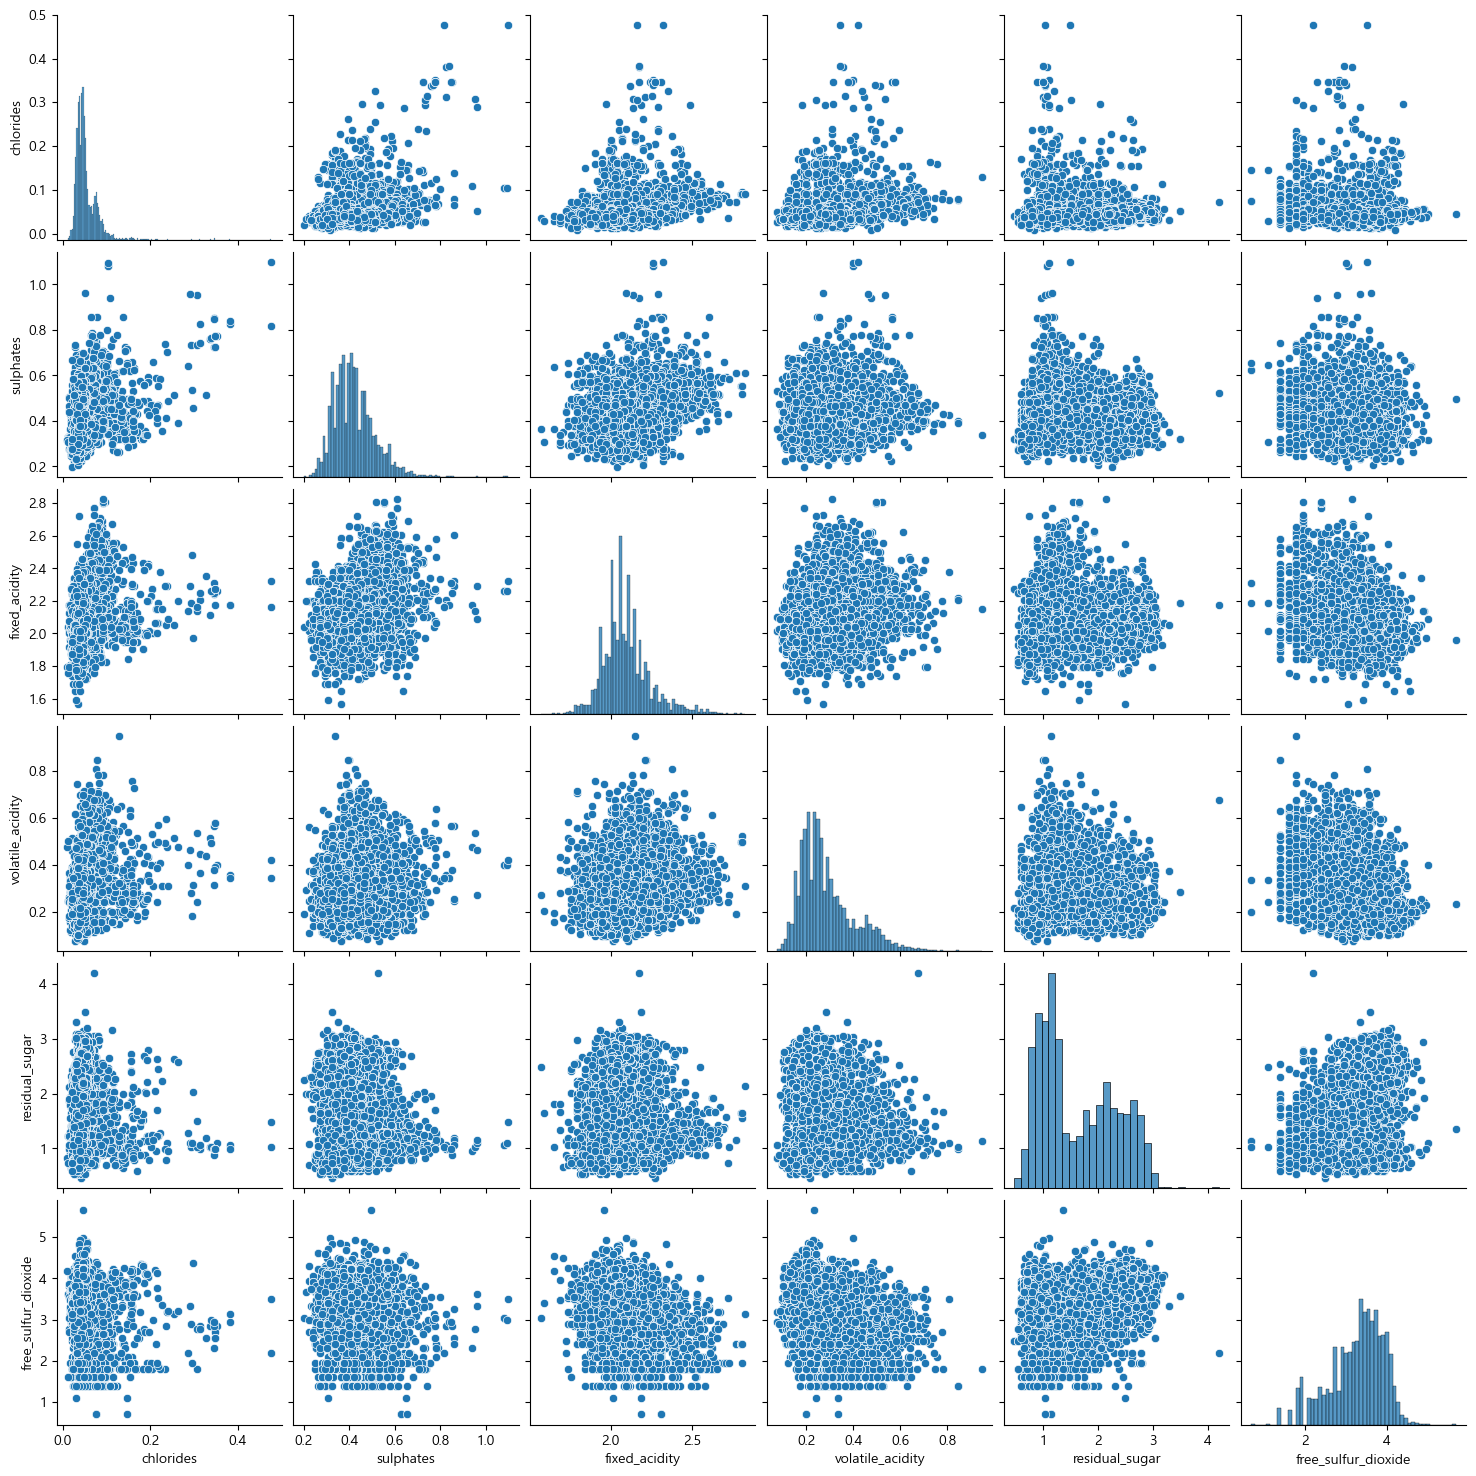

In [28]:
sns.pairplot(np.log1p(X[high_skew_feature]))
X2 = np.log1p(X[high_skew_feature]).copy()
x_train,x_test,y_train,y_test = train_test_split(X2,y,test_size=0.2,random_state=42)
model = LinearRegression()
model.fit(x_train,y_train)
model.score(x_test,y_test)

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train,y_train)

y_predict = model.predict(x_test)


print(f'결정계수 r2_score: {model.score(x_test, y_test)}')

결정계수 r2_score: 0.2597673129771402


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()), ('model', LinearRegression())
])

pipeline.fit(x_train,y_train)
pipeline.score(x_test,y_test)

0.2597673129771396

In [14]:
pd.concat([X,y],axis=1).corr().loc['quality']

fixed_acidity          -0.076743
volatile_acidity       -0.265699
citric_acid             0.085532
residual_sugar         -0.036980
chlorides              -0.200666
free_sulfur_dioxide     0.055463
total_sulfur_dioxide   -0.041385
density                -0.305858
pH                      0.019506
sulphates               0.038485
alcohol                 0.444319
quality                 1.000000
Name: quality, dtype: float64

In [15]:
X

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8


1.0

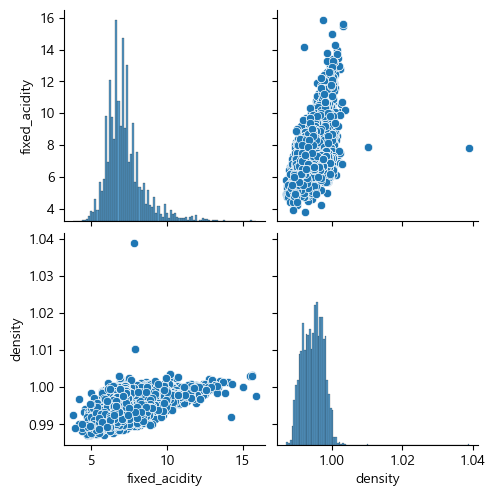

In [17]:
import seaborn as sns
sns.pairplot(X[['fixed_acidity','density']])

x = X[['fixed_acidity']]
y = X['density']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(x_train, y_train)
model.score(x_test,y_test)